In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

In [2]:
data = pd.read_csv('Breast Cancer Detection Classification Master.csv')

# Remove unwanted empty columns if present
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

print(data.shape)
data.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [4]:
x = data.drop(columns=['id', 'diagnosis'])
y = data['diagnosis']

print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [5]:
x = x.apply(pd.to_numeric, errors='coerce')

x = x.fillna(x.median())

print("Missing values:", x.isnull().sum().sum())

Missing values: 0


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['B' 'M']


In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=0
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(398, 30)

(398,)

(171, 30)

(171,)

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [9]:
results = []

for i in [1, 2, 3, 4, 5]:
    
    model = KNeighborsClassifier(
        n_neighbors=i,
        metric='minkowski',
        p=2
    )
    
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    Accuracy_score = metrics.accuracy_score(y_test, y_pred)
    
    results.append(Accuracy_score)

print(results)

[0.935672514619883, 0.9415204678362573, 0.935672514619883, 0.9473684210526315, 0.9590643274853801]


In [10]:
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('KNN [minkowski, neighbor=5]')

KNN [minkowski, neighbor=5]


In [11]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print('Confusion Matrix:\n', conf_mat)

Confusion Matrix:
 [[107   1]
 [  6  57]]


In [12]:
Accuracy_score = metrics.accuracy_score(y_test, y_pred)

print('Accuracy Score:', Accuracy_score)
print('Accuracy in Percentage:', int(Accuracy_score * 100), '%')

Accuracy Score: 0.9590643274853801
Accuracy in Percentage: 95 %


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       108
           1       0.98      0.90      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



[Text(0.5, 1.0, 'KNN [minkowski, neighbor=5]')]

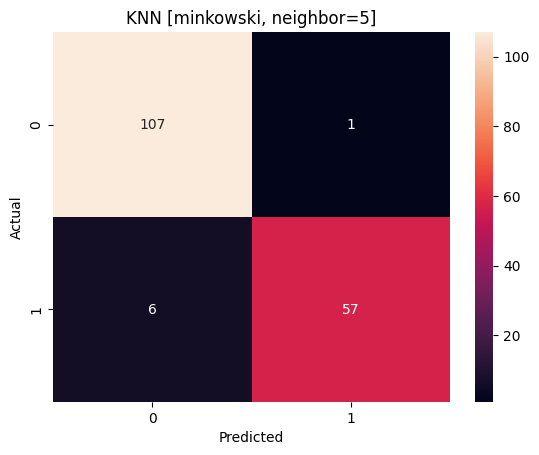

In [14]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True, fmt='d').set(
    title='KNN [minkowski, neighbor=5]'
)

In [15]:
models = pd.DataFrame({
    'n_neighbors': [1, 2, 3, 4, 5],
    'Accuracy Score': results
})

print(models.to_string(index=False))

 n_neighbors  Accuracy Score
           1        0.935673
           2        0.941520
           3        0.935673
           4        0.947368
           5        0.959064


In [16]:
models.sort_values(
    by='Accuracy Score',
    ascending=False
)

,n_neighbors,Accuracy Score
4,5,0.959064
3,4,0.947368
1,2,0.941520
0,1,0.935673
2,3,0.935673
